In [4]:
import serial
import paho.mqtt.client as mqtt
import csv
import json
import time
from datetime import datetime
import threading

# Importamos nuestras credenciales seguras
import secrets_mqtt

# ==========================================
# 1. CONFIGURACIÓN DEL SISTEMA
# ==========================================
MQTT_BROKER = secrets_mqtt.MQTT_BROKER_IP
MQTT_TOPIC = "smarthive/telemetry"

SERIAL_PORT = "COM8" # En Windows COMx, en Linux /dev/ttyUSB0 o /dev/ttyACM0
BAUD_RATE = 115200

CSV_FILENAME = "data/consumo_rpi_produccion.csv"

# Bandera para controlar el apagado seguro de los hilos
system_running = True
ser = None # Variable global para el puerto Serial

# Memoria compartida (State Dictionary) extendida para el PZEM
estado_actual = {
    "cpu_temp": 0.0,
    "cpu_load": 0.0,
    "rssi": 0.0,
    "voltage": 0.0,
    "current": 0.0,
    "power_w": 0.0,
    "energy_wh": 0.0,
    "frequency_hz": 0.0,
    "pf": 0.0
}

# ==========================================
# 2. HILO MQTT (Receptor de LoRa)
# ==========================================
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("[MQTT] Conectado al broker con éxito (Autenticado).")
        client.subscribe(MQTT_TOPIC)
    else:
        print(f"[MQTT ERROR] Fallo al conectar. Código de error: {rc}")

def on_message(client, userdata, msg):
    try:
        data = json.loads(msg.payload.decode())
        estado_actual["cpu_temp"] = data.get("cpu_temp", 0.0)
        estado_actual["cpu_load"] = data.get("cpu_load", 0.0)
        estado_actual["rssi"] = data.get("rssi", 0.0)
        print(f"[MQTT] Telemetría RPi (LoRa) Recibida -> CPU: {estado_actual['cpu_temp']}°C | Carga: {estado_actual['cpu_load']}")
    except Exception as e:
        print(f"[MQTT ERROR] Fallo al parsear JSON: {e}")

mqtt_client = mqtt.Client()
mqtt_client.on_connect = on_connect
mqtt_client.on_message = on_message

# --- AUTENTICACIÓN SEGURA MQTT ---
mqtt_client.username_pw_set(secrets_mqtt.MQTT_USER, secrets_mqtt.MQTT_PASS)

# Conexión e inicio del hilo en segundo plano
try:
    mqtt_client.connect(MQTT_BROKER, 1883, 60)
    mqtt_client.loop_start()
except Exception as e:
    print(f"[MQTT CRITICAL] No se pudo contactar con el broker en {MQTT_BROKER}: {e}")

# ==========================================
# 3. HILO SERIAL (Lector y Controlador PZEM)
# ==========================================
def handle_arduino_serial():
    global ser
    try:
        # Abrimos el puerto
        ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=2)
        print(f"[SERIAL] Puerto {SERIAL_PORT} abierto. Esperando reinicio del Arduino...")

        # El Arduino UNO se reinicia al conectar. Le damos 2 segundos para despertar.
        time.sleep(2)

        # Enviamos el comando de arranque que programaste
        ser.write(b"START\n")
        print("[SERIAL] Comando START enviado. Esperando datos del PZEM...")

        while system_running:
            if ser.in_waiting > 0:
                line = ser.readline().decode('utf-8', errors='ignore').strip()

                if not line:
                    continue

                # Protocolo de Parseo
                if line.startswith("DATA,"):
                    partes = line.split(',')
                    # Aseguramos que nos llegan exactamente los 7 elementos (DATA + 6 valores)
                    if len(partes) == 7:
                        estado_actual["voltage"] = float(partes[1])
                        estado_actual["current"] = float(partes[2])
                        estado_actual["power_w"] = float(partes[3])
                        estado_actual["energy_wh"] = float(partes[4])
                        estado_actual["frequency_hz"] = float(partes[5])
                        estado_actual["pf"] = float(partes[6])

                elif line.startswith("MSG,"):
                    print(f"[ARDUINO] {line.split(',')[1]}")

                elif line.startswith("ERROR,"):
                    print(f"[ARDUINO WARN] {line.split(',')[1]}")

    except Exception as e:
        print(f"[SERIAL CRITICAL] Error con el puerto USB: {e}")

# Arrancamos el hilo Serial
serial_thread = threading.Thread(target=handle_arduino_serial, daemon=True)
serial_thread.start()

# ==========================================
# 4. BUCLE PRINCIPAL (Grabación en CSV)
# ==========================================
print("[SYSTEM] Arrancando DataLogger IoT...")

# Preparar archivo CSV y escribir cabeceras (Solo si el archivo es nuevo)
cabeceras = [
    "Timestamp",
    "Voltaje_V", "Corriente_A", "Potencia_W", "Energia_Wh", "Frecuencia_Hz", "FactorPotencia",
    "RPi_CPU_Temp_C", "RPi_CPU_Load", "LoRa_RSSI"
]

try:
    with open(CSV_FILENAME, mode='a', newline='') as file:
        writer = csv.writer(file)
        if file.tell() == 0:
            writer.writerow(cabeceras)
except FileNotFoundError:
    print(f"[SYSTEM ERROR] La carpeta para {CSV_FILENAME} no existe. Por favor, crea la carpeta 'data/'.")
    system_running = False

if system_running:
    print(f"[SYSTEM] Guardando métricas cada 10 segundos en: {CSV_FILENAME}")
    print("--- Pulsa Ctrl+C para detener la grabación de forma segura ---")

try:
    while system_running:
        time.sleep(10) # Frecuencia de muestreo maestro

        now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

        with open(CSV_FILENAME, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([
                now,
                estado_actual["voltage"],
                estado_actual["current"],
                estado_actual["power_w"],
                estado_actual["energy_wh"],
                estado_actual["frequency_hz"],
                estado_actual["pf"],
                estado_actual["cpu_temp"],
                estado_actual["cpu_load"],
                estado_actual["rssi"]
            ])

        print(f"[LOG] {now} | RPi IA Load: {estado_actual['cpu_load']} -> Consumo: {estado_actual['power_w']} W")

except KeyboardInterrupt:
    print("\n[SYSTEM] Señal de apagado detectada (Ctrl+C). Iniciando cierre seguro...")
    system_running = False

    # Detener Arduino
    if ser and ser.is_open:
        print("[SERIAL] Enviando comando STOP al PZEM...")
        ser.write(b"STOP\n")
        time.sleep(0.5) # Damos tiempo a que se envíe
        ser.close()
        print("[SERIAL] Puerto cerrado.")

    # Detener MQTT
    mqtt_client.loop_stop()
    mqtt_client.disconnect()
    print("[MQTT] Desconectado.")

    print("[SYSTEM] Archivo CSV guardado. Fin del programa.")

C:\Users\Jaime\AppData\Local\Temp\ipykernel_29884\2188720542.py:60: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client()


[MQTT] Conectado al broker con éxito (Autenticado).
[SYSTEM] Arrancando DataLogger IoT...
[SYSTEM] Guardando métricas cada 10 segundos en: data/consumo_rpi_produccion.csv
--- Pulsa Ctrl+C para detener la grabación de forma segura ---
[SERIAL] Puerto COM8 abierto. Esperando reinicio del Arduino...
[SERIAL] Comando START enviado. Esperando datos del PZEM...
[ARDUINO] Iniciando medicion...
[MQTT] Telemetría RPi (LoRa) Recibida -> CPU: 55.7°C | Carga: 0.3
[LOG] 2026-06-01 13:07:38 | RPi IA Load: 0.3 -> Consumo: 8.2 W
[LOG] 2026-06-01 13:07:48 | RPi IA Load: 0.3 -> Consumo: 8.3 W
[LOG] 2026-06-01 13:07:58 | RPi IA Load: 0.3 -> Consumo: 8.3 W
[LOG] 2026-06-01 13:08:08 | RPi IA Load: 0.3 -> Consumo: 8.4 W
[LOG] 2026-06-01 13:08:18 | RPi IA Load: 0.3 -> Consumo: 8.4 W
[LOG] 2026-06-01 13:08:28 | RPi IA Load: 0.3 -> Consumo: 8.3 W
[MQTT] Telemetría RPi (LoRa) Recibida -> CPU: 55.7°C | Carga: 0.5
[LOG] 2026-06-01 13:08:38 | RPi IA Load: 0.5 -> Consumo: 8.5 W
[LOG] 2026-06-01 13:08:48 | RPi IA Lo

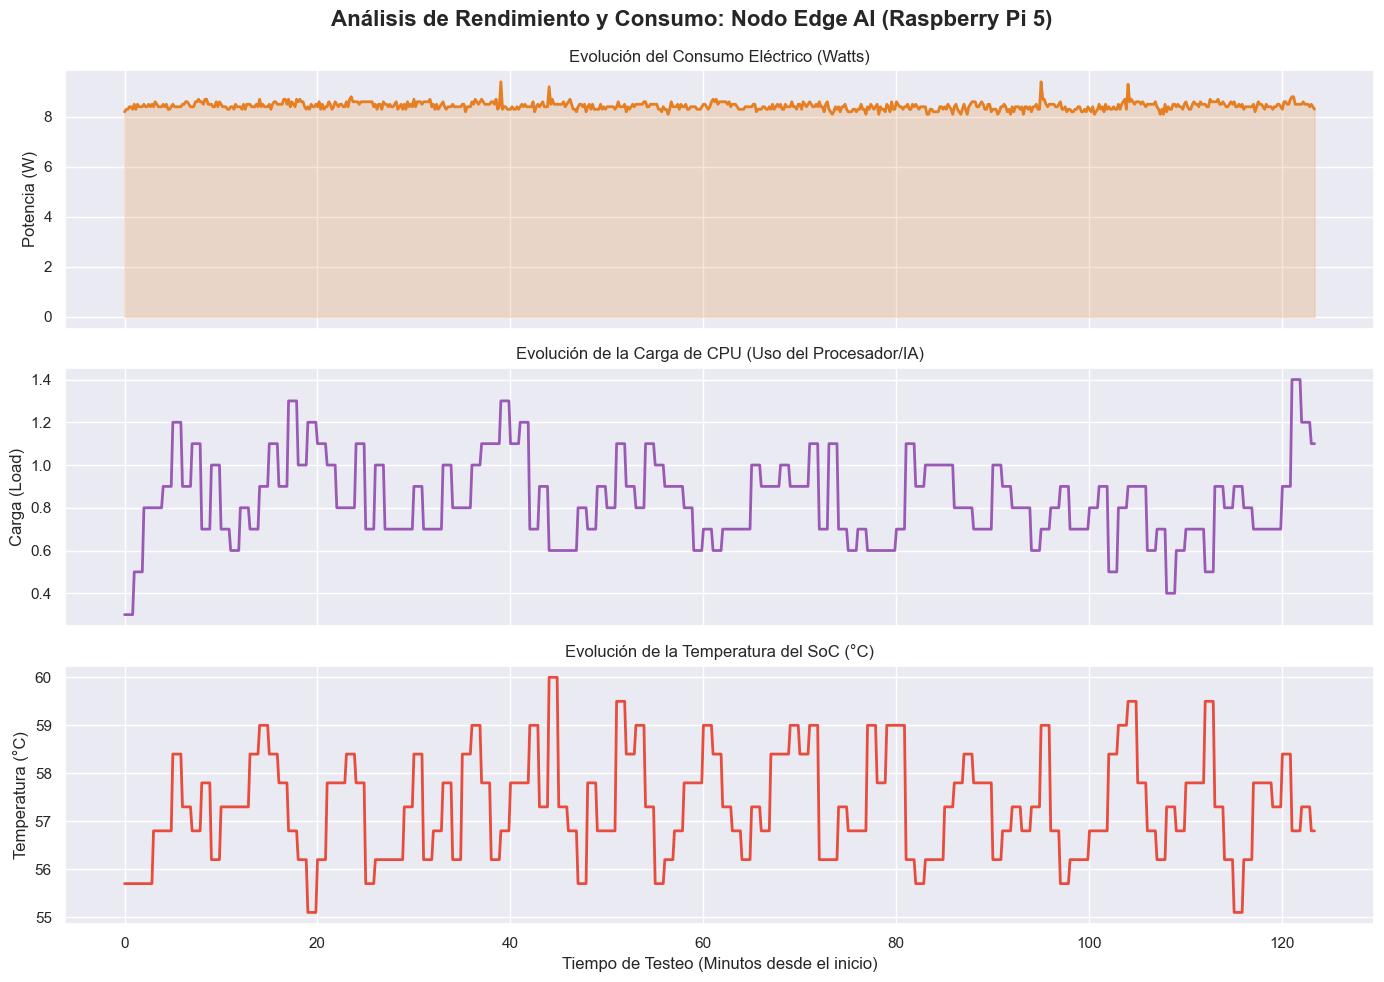

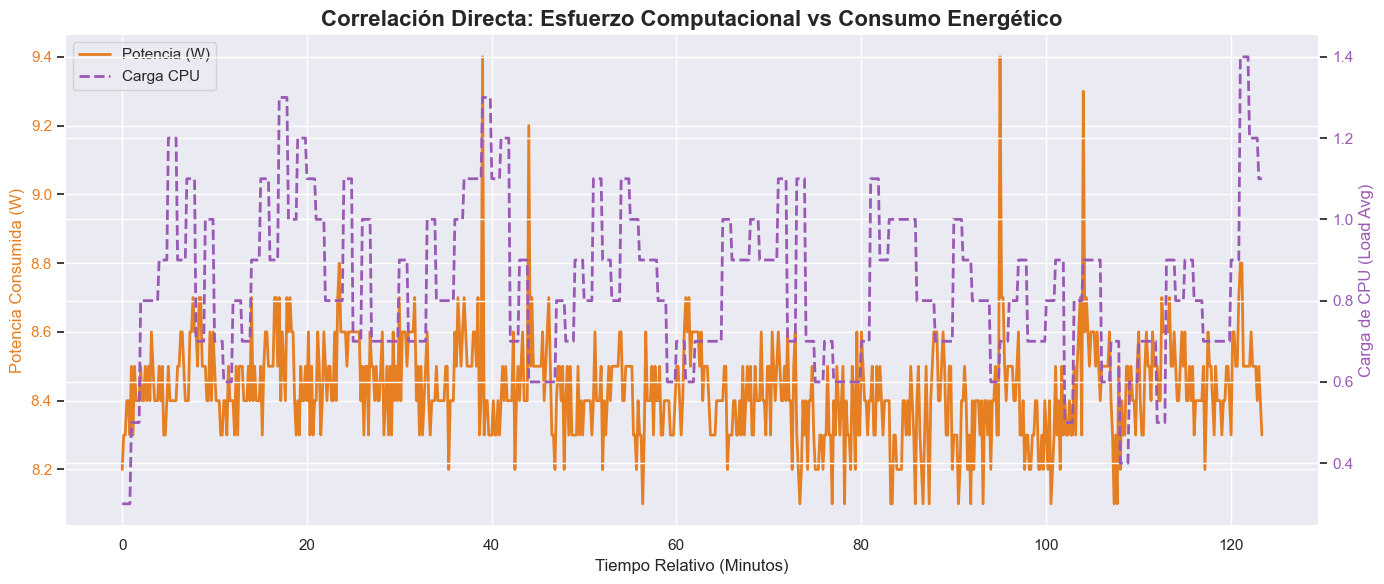

--- RESUMEN DEL TEST ---
Duración total del test: 2.06 horas
Consumo de Potencia Medio: 8.43 W
Pico Máximo de Potencia: 9.40 W
Temperatura Media CPU: 57.32 °C
Pico Máximo de Temperatura: 60.00 °C
Energía real consumida en el test: 17.34 Wh


In [ ]:
# Importar las librerías necesarias para Data Science
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA Y LIMPIEZA DE DATOS
# ==========================================
# Cargar el archivo CSV (ajusta la ruta si es necesario)
archivo_csv = "data/consumo_rpi_produccion.csv"
df = pd.read_csv(archivo_csv)

# Convertir la columna Timestamp (String) a un objeto Datetime de Pandas
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# ==========================================
# 2. TRANSFORMACIÓN: TIEMPO RELATIVO
# ==========================================
# Extraemos el primer instante de tiempo registrado (T0)
tiempo_cero = df['Timestamp'].iloc[0]

# Calculamos la diferencia en segundos de cada fila con respecto a T0 y lo pasamos a minutos/horas
df['Tiempo_Relativo_Minutos'] = (df['Timestamp'] - tiempo_cero).dt.total_seconds() / 60.0
df['Tiempo_Relativo_Horas'] = df['Tiempo_Relativo_Minutos'] / 60.0

# ==========================================
# 3. CONFIGURACIÓN VISUAL (ESTILO)
# ==========================================
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 10)

# ==========================================
# 4. GRÁFICOS INDIVIDUALES (SUBPLOTS)
# ==========================================
fig, axes = plt.subplots(3, 1, sharex=True)
fig.suptitle('Análisis de Rendimiento y Consumo: Nodo Edge AI (Raspberry Pi 5)', fontsize=16, fontweight='bold')

# Gráfica 1: Consumo de Potencia (PZEM)
sns.lineplot(ax=axes[0], data=df, x='Tiempo_Relativo_Minutos', y='Potencia_W', color='#e67e22', linewidth=2)
axes[0].set_title('Evolución del Consumo Eléctrico (Watts)', fontsize=12)
axes[0].set_ylabel('Potencia (W)')
axes[0].fill_between(df['Tiempo_Relativo_Minutos'], df['Potencia_W'], color='#e67e22', alpha=0.2)

# Gráfica 2: Carga de la CPU (Linux Load Average)
sns.lineplot(ax=axes[1], data=df, x='Tiempo_Relativo_Minutos', y='RPi_CPU_Load', color='#9b59b6', linewidth=2)
axes[1].set_title('Evolución de la Carga de CPU (Uso del Procesador/IA)', fontsize=12)
axes[1].set_ylabel('Carga (Load)')

# Gráfica 3: Temperatura Térmica (sysfs)
sns.lineplot(ax=axes[2], data=df, x='Tiempo_Relativo_Minutos', y='RPi_CPU_Temp_C', color='#e74c3c', linewidth=2)
axes[2].set_title('Evolución de la Temperatura del SoC (°C)', fontsize=12)
axes[2].set_ylabel('Temperatura (°C)')
axes[2].set_xlabel('Tiempo de Testeo (Minutos desde el inicio)')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Ajuste para que el título principal no se solape
plt.show()

# ==========================================
# 5. GRÁFICO DE CORRELACIÓN: DATA FUSION (Potencia vs IA)
# ==========================================
# Este gráfico es brutal para defender el proyecto: superpone W y CPU Load en un mismo eje X
fig2, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_title('Correlación Directa: Esfuerzo Computacional vs Consumo Energético', fontsize=16, fontweight='bold')
ax1.set_xlabel('Tiempo Relativo (Minutos)', fontsize=12)

# Eje Y Izquierdo (Consumo Eléctrico en Naranja)
color_potencia = '#e67e22'
ax1.set_ylabel('Potencia Consumida (W)', color=color_potencia, fontsize=12)
line1 = ax1.plot(df['Tiempo_Relativo_Minutos'], df['Potencia_W'], color=color_potencia, linewidth=2, label='Potencia (W)')
ax1.tick_params(axis='y', labelcolor=color_potencia)

# Eje Y Derecho (Carga de CPU en Morado)
ax2 = ax1.twinx()
color_cpu = '#9b59b6'
ax2.set_ylabel('Carga de CPU (Load Avg)', color=color_cpu, fontsize=12)
line2 = ax2.plot(df['Tiempo_Relativo_Minutos'], df['RPi_CPU_Load'], color=color_cpu, linewidth=2, linestyle='--', label='Carga CPU')
ax2.tick_params(axis='y', labelcolor=color_cpu)

# Leyenda unificada
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

# ==========================================
# 6. ESTADÍSTICAS FINALES EN TEXTO
# ==========================================
print("--- RESUMEN DEL TEST ---")
print(f"Duración total del test: {df['Tiempo_Relativo_Horas'].max():.2f} horas")
print(f"Consumo de Potencia Medio: {df['Potencia_W'].mean():.2f} W")
print(f"Pico Máximo de Potencia: {df['Potencia_W'].max():.2f} W")
print(f"Temperatura Media CPU: {df['RPi_CPU_Temp_C'].mean():.2f} °C")
print(f"Pico Máximo de Temperatura: {df['RPi_CPU_Temp_C'].max():.2f} °C")

# Cálculo de Energía Real Consumida durante el test
# Si la media en W multiplicada por las horas del test = Wh consumidos
energia_consumida_wh = df['Potencia_W'].mean() * df['Tiempo_Relativo_Horas'].max()
print(f"Energía real consumida en el test: {energia_consumida_wh:.2f} Wh")